# Testing the visualizations

In [1]:
import xarray as xr

ds = xr.open_dataset("unified_annual_carbon_dataset_2015_2024.nc")
print(ds)

<xarray.Dataset> Size: 29MB
Dimensions:         (time: 10, lat: 180, lon: 360, latitude: 180, longitude: 360)
Coordinates:
  * time            (time) int64 80B 2015 2016 2017 2018 ... 2021 2022 2023 2024
  * lat             (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon             (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * latitude        (latitude) float64 1kB -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * longitude       (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
Data variables:
    growth_rate     (time, lat, lon) float64 5MB ...
    emission        (time, lat, lon) float32 3MB ...
    gosif           (time, lat, lon) float32 3MB ...
    delta_emission  (time, lat, lon) float32 3MB ...
    delta_gosif     (time, lat, lon) float32 3MB ...
    cams_xco2       (time, latitude, longitude) float32 3MB ...
    growth_err      (time, lat, lon) float64 5MB ...
    mean_co2        (time, lat, lon) float64 5MB ...
Attributes:
    descri

In [2]:
print(ds.dims)       # dimensions (time, lat, lon, etc.)
print(ds.coords)     # coordinate variables
print(ds.data_vars)  # actual measured variables


FrozenMappingWarningOnValuesAccess({'time': 10, 'lat': 180, 'lon': 360, 'latitude': 180, 'longitude': 360})
Coordinates:
  * time       (time) int64 80B 2015 2016 2017 2018 2019 ... 2021 2022 2023 2024
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
  * latitude   (latitude) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * longitude  (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
Data variables:
    growth_rate     (time, lat, lon) float64 5MB ...
    emission        (time, lat, lon) float32 3MB ...
    gosif           (time, lat, lon) float32 3MB ...
    delta_emission  (time, lat, lon) float32 3MB ...
    delta_gosif     (time, lat, lon) float32 3MB ...
    cams_xco2       (time, latitude, longitude) float32 3MB ...
    growth_err      (time, lat, lon) float64 5MB ...
    mean_co2        (time, lat, lon) float64 5MB ...


In [12]:
var = ds["mean_co2"]
var

<xarray.DataArray 'mean_co2' (time: 10, lat: 180, lon: 360)> Size: 5MB
array([[[396.17425 , 396.180091, ..., 396.180152, 396.174281],
        [396.156601, 396.151479, ..., 396.156629, 396.15661 ],
        ...,
        [399.716508, 399.716501, ..., 399.716521, 399.716513],
        [399.71291 , 399.712885, ..., 399.714142, 399.714135]],

       [[399.026315, 399.020676, ..., 399.020715, 399.026308],
        [398.994713, 399.000616, ..., 398.994729, 398.99472 ],
        ...,
        [402.583849, 402.583724, ..., 402.584174, 402.584018],
        [402.578781, 402.578653, ..., 402.579976, 402.579889]],

       ...,

       [[414.963978, 414.954681, ..., 414.954617, 414.963981],
        [414.922258, 414.93158 , ..., 414.922034, 414.922146],
        ...,
        [419.243798, 419.243472, ..., 419.24441 , 419.244097],
        [419.256406, 419.256344, ..., 419.257199, 419.25715 ]],

       [[418.038806, 418.042453, ..., 418.042393, 418.038779],
        [417.999641, 417.996125, ..., 417.999433, 417.999539],
        ...,
        [422.385906, 422.385889, ..., 422.386028, 422.385969],
        [422.404244, 422.404169, ..., 422.404602, 422.404508]]],
      shape=(10, 180, 360))
Coordinates:
  * time     (time) int64 80B 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5

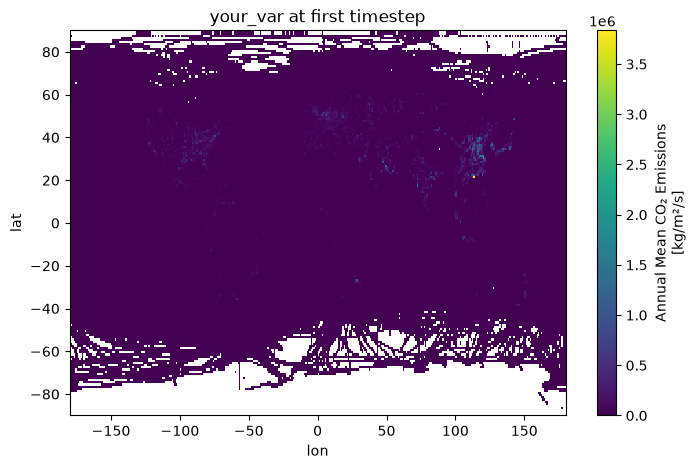

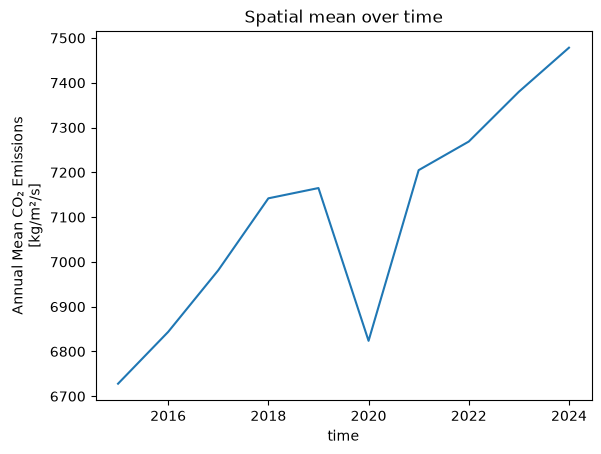

In [36]:
import matplotlib.pyplot as plt

var = ds["emission"]

# 2D map for one time step
var.isel(time=1).plot(figsize=(8, 5))
plt.title("your_var at first timestep")
plt.show()

# Time series (spatial average)
var.mean(dim=[d for d in var.dims if d in ["lat", "latitude", "lon", "longitude"]]).plot()
plt.title("Spatial mean over time")
plt.show()

In [42]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr

ds = xr.open_dataset("unified_annual_carbon_dataset_2015_2024.nc")
out_root = Path("csv_by_variable_and_time")
out_root.mkdir(parents=True, exist_ok=True)

def detect_spatial_dims(da):
    if "lat" in da.dims and "lon" in da.dims:
        return "lat", "lon"
    if "latitude" in da.dims and "longitude" in da.dims:
        return "latitude", "longitude"
    raise ValueError(f"Unsupported spatial dims for {da.name}: {da.dims}")

def time_to_label(t):
    t_arr = np.array(t)
    if np.issubdtype(t_arr.dtype, np.integer):
        return str(int(t))
    try:
        return np.datetime_as_string(np.datetime64(t), unit="D")
    except Exception:
        return str(t)

for var_name, da in ds.data_vars.items():
    if "time" not in da.dims:
        continue

    lat_dim, lon_dim = detect_spatial_dims(da)
    var_out = out_root / var_name
    var_out.mkdir(parents=True, exist_ok=True)

    for t in ds["time"].values:
        da_t = da.sel(time=t)

        lat_vals = da_t[lat_dim].values
        lon_vals = da_t[lon_dim].values
        vals = da_t.values  # 2D array: [lat, lon] or [latitude, longitude]

        # Build flat table directly from array + meshgrid
        lon_grid, lat_grid = np.meshgrid(lon_vals, lat_vals)
    
        vals = np.nan_to_num(da_t.values, nan=0.0, posinf=0.0, neginf=0.0)

        df = pd.DataFrame({
            "lat": lat_grid.ravel(),
            "lon": lon_grid.ravel(),
            var_name: vals.reshape(-1),
        })
        df[var_name] = df[var_name].fillna(0.0)

        out_file = var_out / f"{var_name}_time={time_to_label(t)}.csv"
        df.to_csv(out_file, index=False)#, compression="snappy")

        # Optional sanity check
        non_null = df[var_name].notna().sum()
        if non_null == 0:
            print(f"Warning: {var_name} at time={t} is all NaN in source data")

    print(f"Wrote {var_name}")

Wrote growth_rate
Wrote emission
Wrote gosif
Wrote delta_emission
Wrote delta_gosif
Wrote cams_xco2
Wrote growth_err
Wrote mean_co2


In [43]:
check = pd.read_csv("csv_by_variable_and_time\\emission\\emission_time=2015.csv")
print(check.head())
print(check["emission"].isna().mean(), "fraction NaN")
print(check["emission"].describe())

    lat    lon  emission
0 -89.5 -179.5       0.0
1 -89.5 -178.5       0.0
2 -89.5 -177.5       0.0
3 -89.5 -176.5       0.0
4 -89.5 -175.5       0.0
0.0 fraction NaN
count    6.480000e+04
mean     5.650678e+03
std      4.572364e+04
min      0.000000e+00
25%      1.124687e+00
50%      3.841523e+01
75%      2.440732e+02
max      3.544554e+06
Name: emission, dtype: float64


Rows to plot: 64800


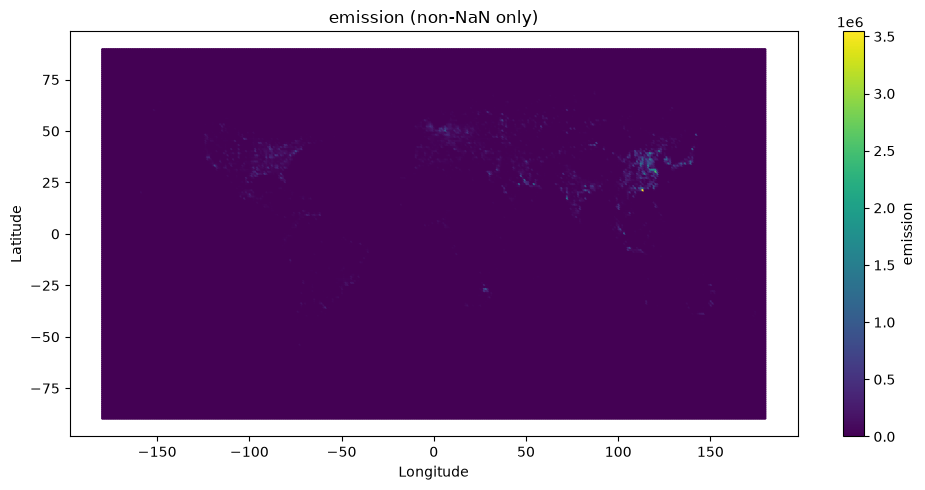

In [46]:
value_cols = [c for c in check.columns if c not in ["lat", "lon"]]
if not value_cols:
    raise ValueError("No data variable column found in check.")
value_col = value_cols[0]
plot_df = check.dropna(subset=["lat", "lon", value_col]).copy()
print("Rows to plot:", len(plot_df))
if len(plot_df) == 0:
    print("No non-NaN values available for plotting.")
else:
    plt.figure(figsize=(10, 5))
    sc = plt.scatter(
    plot_df["lon"], # x-axis
    plot_df["lat"], # y-axis
    c=plot_df[value_col],
    s=6,
    cmap="viridis",
    linewidths=0
    )
    plt.colorbar(sc, label=value_col)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(f"{value_col} (non-NaN only)")
    plt.tight_layout()
    plt.show()

In [47]:
import numpy as np
import pandas as pd

from bokeh.io import output_notebook, show
from bokeh.models import (
    ColumnDataSource, LogColorMapper, ColorBar, BasicTicker, LogTicker,
    NumeralTickFormatter, HoverTool
)
from bokeh.plotting import figure
from bokeh.palettes import Turbo256

output_notebook()

# 1) Detect the value column (everything except lat/lon)
value_cols = [c for c in check.columns if c not in ["lat", "lon"]]
if not value_cols:
    raise ValueError("No data variable column found in check.")
value_col = value_cols[0]

# 2) Keep only finite rows and positive values (required for log scale)
plot_df = check[["lat", "lon", value_col]].copy()
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["lat", "lon", value_col])
plot_df = plot_df[plot_df[value_col] > 0].copy()

if plot_df.empty:
    raise ValueError("No positive non-NaN values available for log-scale plotting.")

# 3) Optional: quantile clipping for better color contrast
#    This prevents a few extreme values from washing out the map.
low_q, high_q = plot_df[value_col].quantile([0.01, 0.99])
plot_df["val_clipped"] = plot_df[value_col].clip(lower=low_q, upper=high_q)

# 4) Build color mapper on clipped values
vmin = float(plot_df["val_clipped"].min())
vmax = float(plot_df["val_clipped"].max())
if vmin <= 0:
    vmin = float(plot_df.loc[plot_df["val_clipped"] > 0, "val_clipped"].min())

mapper = LogColorMapper(palette=Turbo256, low=vmin, high=vmax)

source = ColumnDataSource(plot_df)

# 5) High-resolution interactive figure
p = figure(
    title=f"{value_col} map (log color, non-NaN positive values)",
    width=1400,     # increase resolution
    height=750,     # increase resolution
    x_axis_label="Longitude",
    y_axis_label="Latitude",
    tools="pan,wheel_zoom,box_zoom,lasso_select,reset,save",
    active_scroll="wheel_zoom",
    match_aspect=True
)

# Small markers for dense grid; higher alpha improves visual blending
r = p.circle(
    x="lon",
    y="lat",
    source=source,
    size=3,
    alpha=0.85,
    line_alpha=0,
    fill_color={"field": "val_clipped", "transform": mapper}
)

hover = HoverTool(
    renderers=[r],
    tooltips=[
        ("lon", "@lon{0.00}"),
        ("lat", "@lat{0.00}"),
        (value_col, f"@{value_col}{{0.000}}"),
        ("clipped", "@val_clipped{0.000}")
    ]
)
p.add_tools(hover)

color_bar = ColorBar(
    color_mapper=mapper,
    ticker=LogTicker(),
    formatter=NumeralTickFormatter(format="0.00a"),
    label_standoff=8,
    location=(0, 0),
    title=f"{value_col} (log scale)"
)
p.add_layout(color_bar, "right")

p.grid.visible = True
p.grid.grid_line_alpha = 0.2

show(p)

Loading BokehJS ...